# DEC clustering hypothesis checks

This notebook tests, with saved run artifacts, the hypothesis from the analysis
discussion of `dedup_dec_clustering_analysis_whitened.ipynb`:

> The DEC-trained clustering (KL-divergence loss, one-time k-means init of cluster
> centers at `dec_starting_epoch`, then EM + gradient co-adaptation) ends up in a
> worse configuration than a fresh, post-hoc k-means fit on the same final
> embedding -- because the centers were initialized early and never globally
> re-optimized, not because the final embedding itself is hard to cluster.

Three checks, each isolating one part of the mechanism:

1. **Trained centers vs. fresh k-means on the identical, frozen final embedding**
   -- same data, two different center placements. If trained centers give much
   worse inertia/silhouette than fresh k-means *on the same points*, the
   embedding is fine and the fault is the center placement.
2. **Center drift/trajectory** -- using the full per-EM-step `cluster_centers_np`
   history (`trainers.py:498`, one entry per EM update), check how far centers
   moved from their one-time k-means init, and whether the implied inertia
   (scored against the *final* frozen embedding) ever approaches the fresh
   k-means optimum, or plateaus early.
3. **Sigma sanity check** -- `sigma` is clamped to `[1e-4, 1e4]`
   (`trainers.py:222-223`); a collapsed/blown-up sigma degrades the trained
   assignment independent of center placement.

All loading/feature helpers below are ported verbatim from
`dedup_dec_clustering_analysis_whitened.ipynb` (dedup grouping, whitening,
Student-t soft assignment) so the embedding space matches exactly what training
actually clustered.


In [1]:
print('mew')

mew


In [2]:
import os
import pickle
from itertools import combinations

import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

from sensorium.utility.dedup import dedup_animal, load_coords, load_responses


In [3]:
# ---- which runs to check ----
RUNS_DIR = os.path.join('..', 'training', 'dedup_mean_dec_whitened')
BASE_MULTIPLIER = '1e4'

# single representative run for the deep-dive (checks 2 and 3), and the same
# (seed, cluster_number) already used as the reproduction check in
# dedup_dec_clustering_analysis_whitened.ipynb
REP_SEED = 101
REP_CLUSTER_NUMBER = 10

# small sweep for check 1, kept modest since each run requires a fresh KMeans fit
# on ~10-70k points -- widen freely, this is just enough to see a trend
SWEEP_SEEDS = [42, 101]
SWEEP_CLUSTER_NUMBERS = [5, 10, 20, 30, 50]


def run_dir_for(seed, cluster_number, base_multiplier=BASE_MULTIPLIER):
    return os.path.join(
        RUNS_DIR, f'dedup_mean_dec_whitened_11mice_seed{seed}_cl{cluster_number}_bm{base_multiplier}'
    )


## 1. Shared setup -- session order and per-animal deduplication

Identical to Sections 1-2 of `dedup_dec_clustering_analysis_whitened.ipynb` (data-only, so it doesn't matter which run's checkpoint supplies the session order/sizes).

In [4]:
def get_session_order_and_sizes(run_dir):
    state_dict = torch.load(os.path.join(run_dir, 'model_weights.pth'), map_location='cpu')
    session_ids, sizes = [], []
    for key, value in state_dict.items():
        if key.startswith('readout.') and key.endswith('._features'):
            session_ids.append(key[len('readout.'):-len('._features')])
            sizes.append(value.shape[0])
    return session_ids, sizes


animals, session_sizes = get_session_order_and_sizes(run_dir_for(REP_SEED, REP_CLUSTER_NUMBER))
session_offsets = np.cumsum([0] + session_sizes)
n_neurons_total = int(session_offsets[-1])
print(f'{len(animals)} sessions, {n_neurons_total} neurons total')


11 sessions, 77709 neurons total


In [5]:
coords_per_animal = {}
unique_groups_per_animal = {}
individual_neurons_per_animal = {}

for a, n_neurons in tqdm(list(zip(animals, session_sizes)), desc='dedup per animal'):
    coords_a = load_coords(a)
    responses_a = load_responses(a)
    assert len(coords_a) == len(responses_a) == n_neurons
    unique_groups, individual_neurons = dedup_animal(coords_a, responses_a)
    coords_per_animal[a] = coords_a
    unique_groups_per_animal[a] = unique_groups
    individual_neurons_per_animal[a] = individual_neurons
    print(f'{a}: {n_neurons} neurons -> {len(individual_neurons)} individual + {len(unique_groups)} duplicate groups')


dedup per animal:   9%|▉         | 1/11 [00:07<01:17,  7.79s/it]

23343-5-17: 7334 neurons -> 1389 individual + 1796 duplicate groups


dedup per animal:  18%|█▊        | 2/11 [00:16<01:15,  8.35s/it]

23964-4-22: 8098 neurons -> 1768 individual + 2098 duplicate groups


dedup per animal:  27%|██▋       | 3/11 [00:25<01:09,  8.65s/it]

...

22564-2-12: 8115 neurons -> 8033 individual + 40 duplicate groups


dedup per animal:  91%|█████████ | 10/11 [01:11<00:06,  6.37s/it]

22620-4-15: 7957 neurons -> 1437 individual + 2009 duplicate groups


dedup per animal: 100%|██████████| 11/11 [01:17<00:00,  7.07s/it]

23555-5-12: 6559 neurons -> 1734 individual + 1444 duplicate groups


## 2. Feature/cluster loading helpers

Ported verbatim from `dedup_dec_clustering_analysis_whitened.ipynb` (the whitened-space versions) -- these define the exact space training clustered in: whitened readout features, mean-pooled per dedup group.

In [6]:
def whiten_readouts(cov_ema, readouts, eps=1e-5):
    eye = torch.eye(cov_ema.shape[0], dtype=cov_ema.dtype, device='cpu')
    L = torch.linalg.cholesky(cov_ema + eps * eye)
    whitened_readouts = L.T @ readouts.T
    return whitened_readouts.T


def load_whitened_features(run_dir):
    state_dict = torch.load(os.path.join(run_dir, 'model_weights.pth'), map_location='cpu')
    cov_ema = state_dict['whitener.cov_ema']
    return {
        a: whiten_readouts(cov_ema, state_dict[f'readout.{a}._features'].squeeze()).numpy()
        for a in animals
    }


def load_averaged_embedding(run_dir):
    # Whitened, dedup-averaged (mean-pooled) embedding for one run -- matches what
    # training actually clustered when --kl_after_whitening is set
    # (trainers.py _maybe_whiten + pool_features).
    whitened = load_whitened_features(run_dir)
    parts = []
    for a in animals:
        feats = whitened[a]
        unique_groups = unique_groups_per_animal[a]
        individual_neurons = individual_neurons_per_animal[a]
        grp = (np.stack([feats[list(g)].mean(0) for g in unique_groups])
               if unique_groups else np.empty((0, feats.shape[1])))
        parts.append(np.vstack([feats[individual_neurons], grp]))
    return np.vstack(parts)


def load_cluster_params(run_dir):
    with open(os.path.join(run_dir, 'output_dict.pkl'), 'rb') as f:
        output_dict = pickle.load(f)
    cluster_centers_np = output_dict['cluster_centers_np']  # (n_em_steps, K, D), trainers.py:498/579
    sigma_np = output_dict['sigma_np']
    mixing_coefficients = output_dict['mixing_coefficients']
    return cluster_centers_np, sigma_np, mixing_coefficients


def soft_assignments_mult(encoded_features, cluster_centers, sigma, alpha, p=1, mixing_coefficients=None):
    # Ported verbatim from sensorium.training.trainers.standard_trainer.
    sigma_inv = 1.0 / sigma  # (K, D)
    diff = encoded_features.T.unsqueeze(1) - cluster_centers.unsqueeze(0)  # (N, K, D)
    norm_sigma = torch.sum(diff * sigma_inv * diff, dim=2)  # (N, K)
    det = torch.sum(torch.log(sigma), dim=1)
    log_gamma_top = torch.lgamma((alpha + p) / 2)
    log_gamma_bottom = torch.lgamma(alpha / 2)
    log_pdf = (
        log_gamma_top - log_gamma_bottom - 0.5 * det
        - (p / 2) * torch.log(alpha * torch.pi)
        - ((alpha + p) / 2) * torch.log(1 + (norm_sigma / alpha))
    )
    if mixing_coefficients is not None:
        log_pdf = log_pdf + torch.log(mixing_coefficients.squeeze())
    log_assignments = log_pdf - torch.logsumexp(log_pdf, dim=1, keepdim=True)
    return torch.exp(log_assignments)


def assign_to_fitted_clusters(features_nd, cluster_centers, sigma, mixing_coefficients=None, alpha=1.0):
    # Hard labels under the trained Student-t mixture (no fitting) -- same metric
    # training itself used for the saved `predicted` labels.
    features_dn = torch.from_numpy(features_nd).float().T
    p = features_nd.shape[1]
    q = soft_assignments_mult(
        features_dn, cluster_centers, sigma, torch.tensor(float(alpha)), p, mixing_coefficients
    )
    return q.max(1)[1].numpy()


def euclidean_nearest_center_labels(features_nd, centers_kd):
    # Hard labels by plain Euclidean nearest-center assignment -- the metric the
    # k-means objective itself uses, independent of how centers_kd was obtained.
    diff = features_nd[:, None, :] - centers_kd[None, :, :]
    dist2 = np.sum(diff * diff, axis=2)
    return np.argmin(dist2, axis=1)


def euclidean_inertia(features_nd, centers_kd, labels):
    # sum of squared distances to the assigned center -- same objective as
    # sklearn's KMeans.inertia_, so directly comparable to it.
    return float(np.sum((features_nd - centers_kd[labels]) ** 2))


## 3. Check 1 -- trained centers vs. fresh k-means on the identical, frozen final embedding

For one run at a time: load its final embedding (whitened + dedup-pooled, i.e. exactly
what training clustered), score the **trained** final centers (`cluster_centers_np[-1]`)
against it under the plain Euclidean k-means objective, and compare to a **fresh**
`KMeans` fit from scratch on the same points. Same data, same objective -- the only
thing that differs is where the centers came from.


In [7]:
def evaluate_check1(run_dir, cluster_number, kmeans_seed=42):
    embedding = load_averaged_embedding(run_dir)
    cluster_centers_np, sigma_np, mixing_coefficients = load_cluster_params(run_dir)
    trained_centers = cluster_centers_np[-1]

    # trained centers, scored under the plain Euclidean k-means objective
    trained_labels_euclidean = euclidean_nearest_center_labels(embedding, trained_centers)
    inertia_trained = euclidean_inertia(embedding, trained_centers, trained_labels_euclidean)

    # trained centers, scored under the metric training itself used (Student-t / Mahalanobis)
    cluster_centers_t = torch.from_numpy(trained_centers).float()
    sigma_t = torch.from_numpy(sigma_np).float()
    mixing_t = torch.from_numpy(mixing_coefficients).float() if mixing_coefficients is not None else None
    trained_labels_native = assign_to_fitted_clusters(embedding, cluster_centers_t, sigma_t, mixing_t)

    # fresh k-means, from scratch, on the identical points
    fresh = KMeans(n_clusters=cluster_number, init='k-means++', n_init='auto',
                    max_iter=300, tol=1e-4, random_state=kmeans_seed).fit(embedding)

    return {
        'n_points': embedding.shape[0],
        'inertia_trained_euclidean': inertia_trained,
        'inertia_fresh_kmeans': float(fresh.inertia_),
        'silhouette_trained_euclidean': silhouette_score(embedding, trained_labels_euclidean),
        'silhouette_trained_native': silhouette_score(embedding, trained_labels_native),
        'silhouette_fresh_kmeans': silhouette_score(embedding, fresh.labels_),
        'ari_trained_vs_fresh': adjusted_rand_score(trained_labels_euclidean, fresh.labels_),
    }


In [8]:
check1_rows = []
for cl in tqdm(SWEEP_CLUSTER_NUMBERS, desc='check 1 sweep'):
    for seed in SWEEP_SEEDS:
        run_dir = run_dir_for(seed, cl)
        if not os.path.exists(os.path.join(run_dir, 'output_dict.pkl')):
            print(f'skipping seed={seed} cl={cl}: run not found/finished')
            continue
        result = evaluate_check1(run_dir, cl)
        result.update(seed=seed, cluster_number=cl)
        check1_rows.append(result)

for r in check1_rows:
    ratio = r['inertia_trained_euclidean'] / r['inertia_fresh_kmeans']
    print(f"seed={r['seed']:<4} K={r['cluster_number']:<3} "
          f"inertia trained/fresh={ratio:6.2f}x  "
          f"silhouette trained(native)={r['silhouette_trained_native']:+.3f}  "
          f"silhouette fresh={r['silhouette_fresh_kmeans']:+.3f}  "
          f"ARI(trained,fresh)={r['ari_trained_vs_fresh']:.3f}")


check 1 sweep: 100%|██████████| 5/5 [13:35<00:00, 163.11s/it]

seed=42   K=5   inertia trained/fresh=  1.02x  silhouette trained(native)=+0.019  silhouette fresh=+0.038  ARI(trained,fresh)=0.343
seed=101  K=5   inertia trained/fresh=  1.02x  silhouette trained(native)=+0.010  silhouette fresh=+0.039  ARI(trained,fresh)=0.322
seed=42   K=10  inertia trained/fresh=  1.04x  silhouette trained(native)=-0.027  silhouette fresh=+0.021  ARI(trained,fresh)=0.373
seed=101  K=10  inertia trained/fresh=  1.04x  silhouette trained(native)=-0.023  silhouette fresh=+0.022  ARI(trained,fresh)=0.315
seed=42   K=20  inertia trained/fresh=  1.04x  silhouette trained(native)=-0.035  silhouette fresh=+0.001  ARI(trained,fresh)=0.291
seed=101  K=20  inertia trained/fresh=  1.05x  silhouette trained(native)=-0.040  silhouette fresh=+0.001  ARI(trained,fresh)=0.241
seed=42   K=30  inertia trained/fresh=  1.04x  silhouette trained(native)=-0.039  silhouette fresh=-0.003  ARI(trained,fresh)=0.247
seed=101  K=30  inertia trained/fresh=  1.05x  silhouette trained(native)=-0

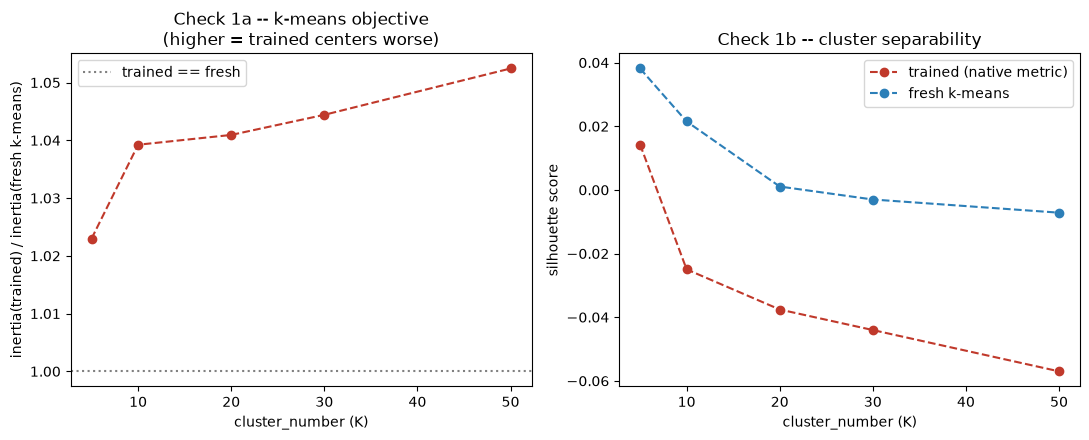

In [9]:
cls = sorted(set(r['cluster_number'] for r in check1_rows))
inertia_ratio_mean = [np.mean([r['inertia_trained_euclidean'] / r['inertia_fresh_kmeans']
                                for r in check1_rows if r['cluster_number'] == cl]) for cl in cls]
sil_trained_mean = [np.mean([r['silhouette_trained_native'] for r in check1_rows if r['cluster_number'] == cl])
                     for cl in cls]
sil_fresh_mean = [np.mean([r['silhouette_fresh_kmeans'] for r in check1_rows if r['cluster_number'] == cl])
                   for cl in cls]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(cls, inertia_ratio_mean, ls='--', marker='o', color='#c0392b')
axes[0].axhline(1.0, color='grey', ls=':', label='trained == fresh')
axes[0].set_xlabel('cluster_number (K)')
axes[0].set_ylabel('inertia(trained) / inertia(fresh k-means)')
axes[0].set_title('Check 1a -- k-means objective\n(higher = trained centers worse)')
axes[0].legend()

axes[1].plot(cls, sil_trained_mean, ls='--', marker='o', label='trained (native metric)', color='#c0392b')
axes[1].plot(cls, sil_fresh_mean, ls='--', marker='o', label='fresh k-means', color='#2c7fb8')
axes[1].set_xlabel('cluster_number (K)')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('Check 1b -- cluster separability')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Check 2 -- center drift / trajectory

`cluster_centers_np` (`trainers.py:498`, `:579`) stores one snapshot **per EM update
step** from `dec_starting_epoch` onward. Using the representative run
(`seed=REP_SEED`, `cluster_number=REP_CLUSTER_NUMBER`):

- how far did the final centers move from their one-time k-means init?
- scored against the *same, fixed, final* embedding at every step: does the implied
  k-means inertia trend toward the fresh-k-means optimum, or plateau early?


In [10]:
rep_run_dir = run_dir_for(REP_SEED, REP_CLUSTER_NUMBER)
rep_embedding = load_averaged_embedding(rep_run_dir)
rep_cluster_centers_np, rep_sigma_np, rep_mixing_coefficients = load_cluster_params(rep_run_dir)
n_steps = rep_cluster_centers_np.shape[0]
print(f'{n_steps} EM-step snapshots, K={rep_cluster_centers_np.shape[1]}, D={rep_cluster_centers_np.shape[2]}')

# drift from the one-time k-means init to the final centers, per cluster
drift_from_init = np.linalg.norm(rep_cluster_centers_np[-1] - rep_cluster_centers_np[0], axis=1)
# typical inter-cluster spacing at the end, for scale
final_centers = rep_cluster_centers_np[-1]
pairwise = np.linalg.norm(final_centers[:, None, :] - final_centers[None, :, :], axis=2)
typical_spacing = pairwise[~np.eye(len(final_centers), dtype=bool)].mean()

print('drift from init per cluster:', np.round(drift_from_init, 3))
print(f'mean drift from init: {drift_from_init.mean():.3f}  vs. typical final inter-cluster spacing: {typical_spacing:.3f}')


3745 EM-step snapshots, K=10, D=96
drift from init per cluster: [0.54  0.965 0.8   0.542 0.539 0.667 0.426 0.996 0.793 0.37 ]
mean drift from init: 0.664  vs. typical final inter-cluster spacing: 0.536


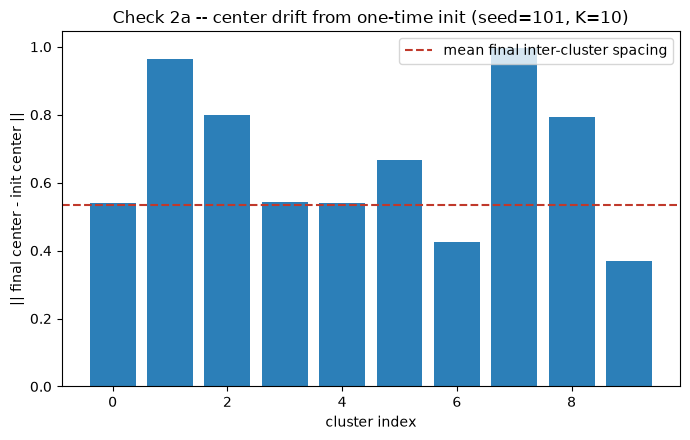

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(np.arange(len(drift_from_init)), drift_from_init, color='#2c7fb8')
ax.axhline(typical_spacing, color='#c0392b', ls='--', label='mean final inter-cluster spacing')
ax.set_xlabel('cluster index')
ax.set_ylabel('|| final center - init center ||')
ax.set_title(f'Check 2a -- center drift from one-time init (seed={REP_SEED}, K={REP_CLUSTER_NUMBER})')
ax.legend()
plt.tight_layout()
plt.show()


In [12]:
# inertia trajectory: subsample steps (full history can be thousands of EM updates)
# and score every snapshot's centers, via Euclidean nearest-center assignment,
# against the SAME fixed final embedding
n_snapshot_points = min(200, n_steps)
step_idcs = np.unique(np.linspace(0, n_steps - 1, n_snapshot_points, dtype=int))

inertia_trajectory = []
for t in tqdm(step_idcs, desc='scoring center snapshots'):
    centers_t = rep_cluster_centers_np[t]
    labels_t = euclidean_nearest_center_labels(rep_embedding, centers_t)
    inertia_trajectory.append(euclidean_inertia(rep_embedding, centers_t, labels_t))
inertia_trajectory = np.array(inertia_trajectory)

rep_check1 = evaluate_check1(rep_run_dir, REP_CLUSTER_NUMBER)
print(f"final trained inertia (Euclidean): {rep_check1['inertia_trained_euclidean']:.1f}")
print(f"fresh k-means inertia:             {rep_check1['inertia_fresh_kmeans']:.1f}")


scoring center snapshots: 100%|██████████| 200/200 [00:21<00:00,  9.34it/s]


final trained inertia (Euclidean): 41457.1
fresh k-means inertia:             39902.5


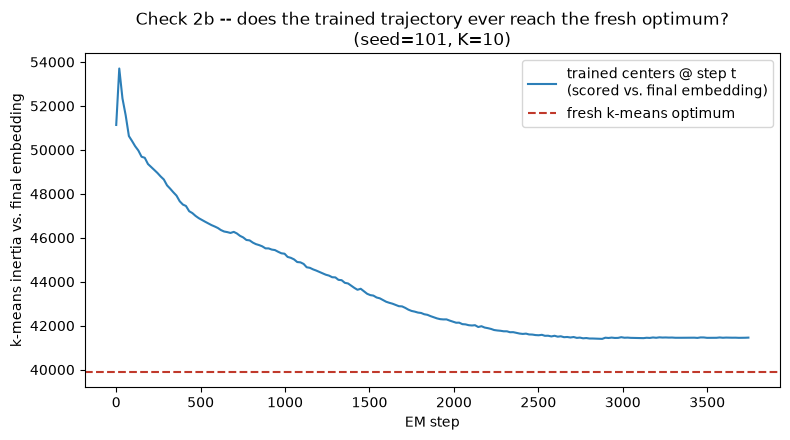

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(step_idcs, inertia_trajectory, color='#2c7fb8', label='trained centers @ step t\n(scored vs. final embedding)')
ax.axhline(rep_check1['inertia_fresh_kmeans'], color='#c0392b', ls='--', label='fresh k-means optimum')
ax.set_xlabel('EM step')
ax.set_ylabel('k-means inertia vs. final embedding')
ax.set_title(f'Check 2b -- does the trained trajectory ever reach the fresh optimum?\n(seed={REP_SEED}, K={REP_CLUSTER_NUMBER})')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Check 3 -- sigma sanity check

`sigma` is clamped to `[1e-4, 1e4]` in `EM_t_mult` (`trainers.py:222-223`). A
cluster/dimension sitting at either clamp bound means its Student-t width is
degenerate (near-delta or near-uniform), which distorts the soft/hard assignment
independent of where the centers are.


In [14]:
def evaluate_check3(run_dir, lower=1e-4, upper=1e4, rtol=1e-3):
    _, sigma_np, _ = load_cluster_params(run_dir)
    at_lower = np.isclose(sigma_np, lower, rtol=rtol)
    at_upper = np.isclose(sigma_np, upper, rtol=rtol)
    return {
        'sigma_min': float(sigma_np.min()),
        'sigma_max': float(sigma_np.max()),
        'frac_at_lower_clamp': float(at_lower.mean()),
        'frac_at_upper_clamp': float(at_upper.mean()),
        'sigma_flat': sigma_np.ravel(),
    }


check3_rows = []
for cl in SWEEP_CLUSTER_NUMBERS:
    for seed in SWEEP_SEEDS:
        run_dir = run_dir_for(seed, cl)
        if not os.path.exists(os.path.join(run_dir, 'output_dict.pkl')):
            continue
        r = evaluate_check3(run_dir)
        r.update(seed=seed, cluster_number=cl)
        check3_rows.append(r)

for r in check3_rows:
    print(f"seed={r['seed']:<4} K={r['cluster_number']:<3} "
          f"sigma range=[{r['sigma_min']:.2e}, {r['sigma_max']:.2e}]  "
          f"frac@lower={r['frac_at_lower_clamp']:.3f}  frac@upper={r['frac_at_upper_clamp']:.3f}")


seed=42   K=5   sigma range=[1.00e-04, 1.25e-01]  frac@lower=0.019  frac@upper=0.000
seed=101  K=5   sigma range=[1.00e-04, 1.47e-01]  frac@lower=0.021  frac@upper=0.000
seed=42   K=10  sigma range=[1.00e-04, 3.06e-01]  frac@lower=0.021  frac@upper=0.000
seed=101  K=10  sigma range=[1.00e-04, 1.14e-01]  frac@lower=0.017  frac@upper=0.000
seed=42   K=20  sigma range=[1.00e-04, 1.52e-01]  frac@lower=0.016  frac@upper=0.000
seed=101  K=20  sigma range=[1.00e-04, 1.51e-01]  frac@lower=0.019  frac@upper=0.000
seed=42   K=30  sigma range=[1.00e-04, 1.83e-01]  frac@lower=0.019  frac@upper=0.000
seed=101  K=30  sigma range=[1.00e-04, 1.80e-01]  frac@lower=0.028  frac@upper=0.000
seed=42   K=50  sigma range=[1.00e-04, 1.63e-01]  frac@lower=0.019  frac@upper=0.000
seed=101  K=50  sigma range=[1.00e-04, 1.90e-01]  frac@lower=0.026  frac@upper=0.000


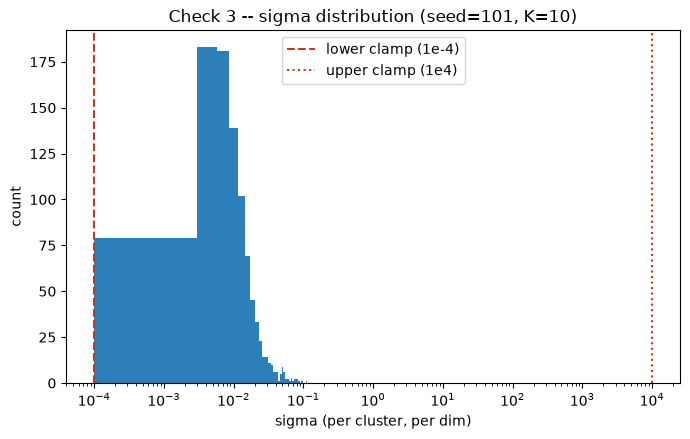

fraction of (cluster, dim) entries at the lower clamp: 0.017


In [15]:
rep_check3 = evaluate_check3(rep_run_dir)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(rep_check3['sigma_flat'], bins=40, color='#2c7fb8')
ax.axvline(1e-4, color='#c0392b', ls='--', label='lower clamp (1e-4)')
ax.axvline(1e4, color='#c0392b', ls=':', label='upper clamp (1e4)')
ax.set_xscale('log')
ax.set_xlabel('sigma (per cluster, per dim)')
ax.set_ylabel('count')
ax.set_title(f'Check 3 -- sigma distribution (seed={REP_SEED}, K={REP_CLUSTER_NUMBER})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"fraction of (cluster, dim) entries at the lower clamp: {rep_check3['frac_at_lower_clamp']:.3f}")


## 6. Reading the results

- **Check 1**: if `inertia(trained)/inertia(fresh)` (panel 1a) is well above 1 and
  the trained silhouette (panel 1b) sits below the fresh-k-means silhouette across
  `K`, the final embedding is clusterable just fine -- the trained *center
  placement* is what's worse.
- **Check 2**: if the drift bars (2a) are small relative to the final inter-cluster
  spacing, and the inertia trajectory (2b) plateaus well above the fresh-k-means
  line early in training rather than converging toward it, that's the mechanism --
  centers got stuck near their one-time init and never globally re-optimized
  against the representation that kept evolving under them.
- **Check 3**: any sizeable `frac_at_lower_clamp`/`frac_at_upper_clamp` means some
  clusters' Student-t width degenerated, which independently corrupts the trained
  assignment regardless of where the centers sit -- worth flagging separately from
  the drift story.
